<a href="https://colab.research.google.com/github/Rupashree0806/rupa-codeboosters-2026/blob/main/Day2/Day2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("All libraires imported successfully!")
print(f"pandas version:{pd.__version__}")
print(f"sqlite3 version:{sqlite3.version}")

All libraires imported successfully!
pandas version:2.2.2
sqlite3 version:2.6.0


In [9]:
df=pd.read_csv('student_performance.csv')
print(f"Dataset loaded:{df.shape[0]} students,{df.shape[1]} columns")
print(f"columns:{df.columns.tolist()}")
print("\nFirst 3 rows:")
df.head(3)

Dataset loaded:30 students,13 columns
columns:['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']

First 3 rows:


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


In [35]:
conn=sqlite3.connect('college.db')
cursor=conn.cursor()
df.to_sql(
    'students', #TABLENAME
    conn,   #CONNECTION
    if_exists='replace',
    index=False
)
cursor.execute("SELECT COUNT(*) FROM STUDENTS")
count=cursor.fetchone()[0]
print(f"Database 'college.db' created successfully")
print(f"table 'students' has {count} rows" )

Database 'college.db' created successfully
table 'students' has 30 rows


In [14]:
query1="""
SELECT  student_id, name, department,math_score,attendance_percentage
From students
LIMIT 10
"""
cursor.execute(query1)
result1 = cursor.fetchall()
print("Query 1: First 10 students (SELECT + LIMIT)")
for row in result1:
    print(row)

Query 1: First 10 students (SELECT + LIMIT)
(1001, 'Aarav Sharma', 'Computer Science', 85, 92)
(1002, 'Priya Patel', 'Computer Science', 76, 87)
(1003, 'Rohit Verma', 'Electronics', 65, 78)
(1004, 'Sneha Reddy', 'Mechanical', 70, 95)
(1005, 'Arjun Nair', 'Computer Science', 92, 90)
(1006, 'Meera Joshi', 'Electronics', 58, 72)
(1007, 'Kiran Kumar', 'Civil', 73, 85)
(1008, 'Divya Singh', 'Computer Science', 88, 96)
(1009, 'Rahul Mishra', 'Mechanical', 62, 68)
(1010, 'Ananya Das', 'Computer Science', 95, 98)


In [38]:
query2 = """
SELECT name, student_id
FROM students
LIMIT 5
"""
cursor.execute(query2)
result2 = cursor.fetchall()
print("Query 2: First 5 students (SELECT name, student_id)")
for row in result2:
    print(row)

Query 2: First 5 students (SELECT name, student_id)
('Aarav Sharma', 1001)
('Priya Patel', 1002)
('Rohit Verma', 1003)
('Sneha Reddy', 1004)
('Arjun Nair', 1005)


In [36]:
query3 = """
SELECT name, student_id
FROM students
LIMIT 5
"""
cursor.execute(query3)
result3 = cursor.fetchall()
print("Query 3: First 5 students (SELECT name, student_id) from new cell")
for row in result3:
    print(row)

Query 3: First 5 students (SELECT name, student_id) from new cell
('Aarav Sharma', 1001)
('Priya Patel', 1002)
('Rohit Verma', 1003)
('Sneha Reddy', 1004)
('Arjun Nair', 1005)


In [22]:
query4 = """
SELECT name, student_id,math_score
FROM students
LIMIT 5
"""
cursor.execute(query4)
result4 = cursor.fetchall()
print("Query 4: First 5 students (SELECT name, student_id,math_score) from new cell")
for row in result4:
    print(row)

Query 4: First 5 students (SELECT name, student_id,math_score) from new cell
('Aarav Sharma', 1001, 85)
('Priya Patel', 1002, 76)
('Rohit Verma', 1003, 65)
('Sneha Reddy', 1004, 70)
('Arjun Nair', 1005, 92)


In [39]:
def run_query(query, title):
    cursor.execute(query)
    results = cursor.fetchall()
    print(title)
    for row in results:
        print(row)
query4= """
SELECT name,department,attendance_percentage
FROM students
WHERE attendance_percentage>93 AND department !='Mechanical'
ORDER BY attendance_percentage DESC
LIMIT 3
"""

result4=run_query(query4,"Query4: TOP 5 STUDENTS WITH HIGH ATTENDANCE")

Query4: TOP 5 STUDENTS WITH HIGH ATTENDANCE
('Ananya Das', 'Computer Science', 98)
('Tanvi Mehta', 'Computer Science', 97)
('Divya Singh', 'Computer Science', 96)


In [40]:
query5="""
SELECT
department,
COUNT(*)                                 AS num_students,
ROUND(AVG(math_score),2)                 AS avg_math,
ROUND(AVG(science_score),2)              AS Avg_science,
ROUND(AVG(programming_score),2)          AS Avg_programming_score,
ROUND(AVG(attendance_percentage),2)      AS avg_attendance
FROM students
GROUP BY department
ORDER BY num_students DESC
"""
result5=run_query(query5,"Query5: DEPARTMENT ANALYSIS")



Query5: DEPARTMENT ANALYSIS
('Computer Science', 13, 85.62, 84.46, 89.23, 90.69)
('Mechanical', 6, 71.0, 76.5, 49.33, 83.5)
('Electronics', 6, 71.0, 74.17, 61.5, 80.33)
('Civil', 5, 63.4, 66.6, 40.6, 74.6)


In [41]:
query6="""
    SELECT
        department,
        AVG(math_score) AS avg_math_score,
        COUNT(*) AS num_students,
        ROUND(AVG(math_score),2) AS avg_math_rounded
    FROM students
    GROUP BY department
    ORDER BY num_students DESC
"""
run_query(query6, "Query6: Departmental Math Score Analysis")

Query6: Departmental Math Score Analysis
('Computer Science', 85.61538461538461, 13, 85.62)
('Mechanical', 71.0, 6, 71.0)
('Electronics', 71.0, 6, 71.0)
('Civil', 63.4, 5, 63.4)


In [42]:
query7="""
    SELECT
        gender,
        COUNT(*) AS num_students,
        ROUND(AVG(math_score), 2) AS avg_math_score,
        ROUND(AVG(science_score), 2) AS avg_science_score,
              ROUND(AVG(attendance_percentage), 2) AS avg_attendance_percentage
    FROM students
    GROUP BY gender
    ORDER BY gender
"""

run_query(query7, "Query7: Gender-wise Analysis of Scores and Attendance")

Query7: Gender-wise Analysis of Scores and Attendance
('Female', 15, 78.47, 81.2, 88.53)
('Male', 15, 73.67, 74.47, 80.47)


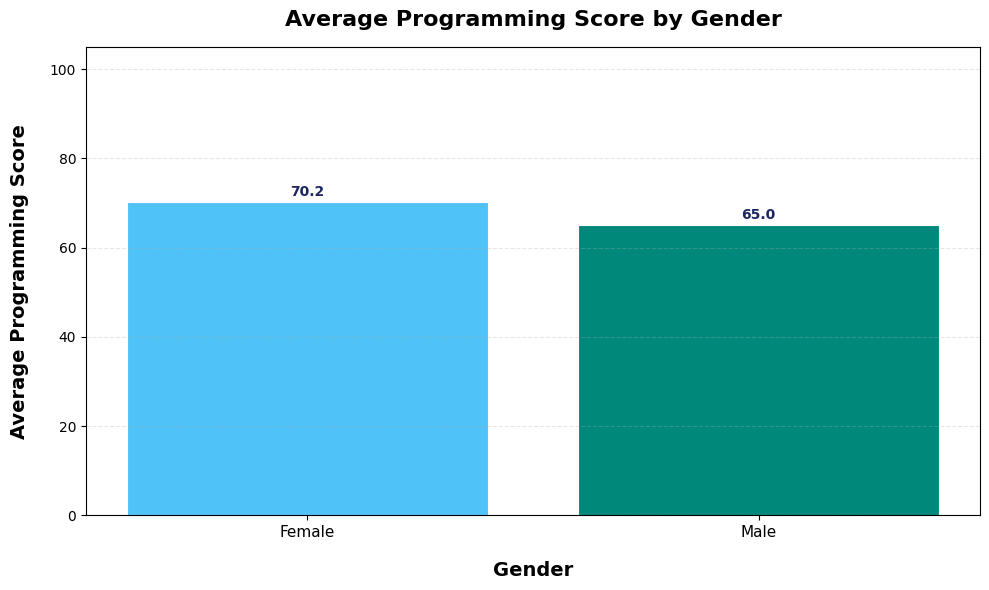

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

chart1_sql="""
SELECT gender,ROUND(AVG(programming_score),2) AS avg_score
FROM students
GROUP BY gender
ORDER BY avg_score DESC
"""
chart1_df=pd.read_sql_query(chart1_sql,conn)

fig,ax=plt.subplots(figsize=(10,6))

bar_colors=['#4FC3F7','#00897B','#E67E32','#8E44AD'] # Corrected hex color code

bars=ax.bar(
    chart1_df['gender'], # Corrected variable name
    chart1_df['avg_score'],   # Changed to avg_score
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8
)

for bar in bars:
   height=bar.get_height()
   ax.text(
       bar.get_x()+bar.get_width()/2,
       height+0.8,
       f'{height:.1f}', # Changed to .1f for one decimal place
       ha='center',
       va='bottom',
       fontsize=10,
       fontweight='bold',
       color='#1E2761'
   )

# Moved these plotting commands outside the loop
ax.set_title('Average Programming Score by Gender',fontsize=16,fontweight='bold',pad=15)
ax.set_xlabel('Gender',fontsize=14,fontweight='bold',labelpad=15) # Corrected label
ax.set_ylabel('Average Programming Score',fontsize=14,fontweight='bold',labelpad=15) # Corrected label
ax.set_ylim(0,105)
ax.tick_params(axis='x',labelsize=11)
ax.grid(axis='y',alpha=0.3,linestyle='--')

plt.tight_layout()
plt.show()

In [44]:
query9="""
SELECT gender,
ROUND(AVG(programming_score), 2) AS avg_programming_score
FROM students
GROUP BY gender
ORDER BY avg_programming_score DESC
"""
run_query(query9, "Query9: average programming score")

Query9: average programming score
('Female', 70.2)
('Male', 65.0)


In [46]:
query10="""
SELECT department,
ROUND(AVG(programming_score), 2) AS avg_programming_score
FROM students
WHERE AVG(programming_score)>85
GROUP BY department
ORDER BY avg_programming_score DESC
"""
run_query(query10, "Query10: average programming score")

Query10: Departments with average programming score above 85
('Computer Science', 89.23)
